# Task 1: Linear Discriminant Analysis


In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import confusion_matrix, classification_report, precision_score

def plot_digits(data):
    # Function to visualize the digits from data
    fig, ax = plt.subplots(10, 10, figsize=(8, 8),
                           subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i].reshape(8, 8), cmap='binary')
        im.set_clim(0, 16)

We load digits datasets. It contains 1797 images, each (64,) shape (8x8).

In [2]:
digits = load_digits()
print(f"Data shape : {digits.data.shape}")
print(f"Target shape : {digits.target.shape}")

Data shape : (1797, 64)
Target shape : (1797,)


### 1.1 Visualize a few digit images from the dataset.


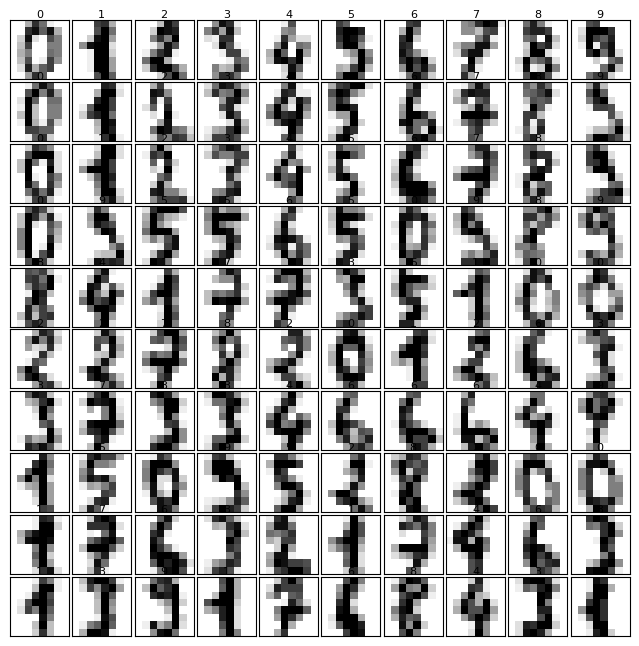

In [3]:
# Write your code here

# Function to visualize the digits from data
def plot_digits(data, labels):
    fig, ax = plt.subplots(10, 10, figsize=(8, 8),
                           subplot_kw=dict(xticks=[], yticks=[]))
    #This allows us to see 100 generated numerical images
    #consisting of 10 rows and 10 columns using plt.subplots(10, 10).
    #figsize=(8,8) sets the overall size of the figure.
    #subplot_kw=dict(xticks=[], yticks=[]) removes the tick 
    # marks from each subplot for a cleaner look.
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    #This adjusts the spacing between subplots to minimize gaps.
    for i, axi in enumerate(ax.flat):
        # reshape each 64-length vector into 8x8 image and 
        # we are flattening the ax series into a single dimension.
        im = axi.imshow(data[i].reshape(8, 8), cmap='binary')
        #data[i] = represents the properties of the i-th digit
        #reshape(8, 8) converts the 1D array of length 64 into a 2D array of shape 8x8.
        #cmap='binary' displays the image in black and white.
        im.set_clim(0, 16)       # pixel intensity between 0–16
        axi.set_title(str(labels[i]), fontsize=8, pad=2)
    plt.show()

# Call the function to plot 100 digit images
plot_digits(digits.data, digits.target)

### 1.2 Split dataset into train and test datasets. Apply PCA.



In [4]:
X = digits.data
y = digits.target
classes = np.unique(y)
test_ratio = 0.3
#here we are splitting the dataset into training and testing sets.
n_samples = X.shape[0]
# X.shape[0]= total sample size
n_test = int(n_samples * test_ratio)
#here we are calculating the number of test samples based on the test_ratio.
n_train = n_samples - n_test
#here we are calculating the number of training samples.


rng = np.random.default_rng(seed=42)
#At this line, the code initializes a random number generator (RNG) using NumPy's 
#default_rng function with a specified seed value of 42.
indices = np.arange(n_samples)
#This line creates an array of indices ranging from 0 to n_samples - 1.
rng.shuffle(indices)
#This line shuffles the array of indices randomly using the previously initialized RNG.

train_idx = indices[:n_train]
#here we are selecting the first n_train indices from the shuffled indices array to form the training set.
test_idx = indices[n_train:]
#here we are selecting the remaining indices from the shuffled indices array to form the testing set.

X_train, X_test = X[train_idx], X[test_idx]
#For here, we are using the train_idx and test_idx arrays to index into the original dataset X,
#creating the training set X_train and the testing set X_test.
y_train, y_test = y[train_idx], y[test_idx]
#Similarly, we are creating the training labels y_train and testing labels y_test using the same indices.
# This results in a randomized split of the dataset into training and testing subsets.

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

scaler = StandardScaler()
# Scale data to zero mean and unit variance
X_train_scaled = scaler.fit_transform(X_train)
#here we are fitting the scaler to the training data and transforming it.
X_test_scaled = scaler.transform(X_test)
#also we are transforming the test data using the same scaler fitted on the training data.

pca = PCA(n_components=50)
#here we are initializing PCA to reduce the data to 50 principal components.
X_train_pca = pca.fit_transform(X_train_scaled)
#here we are fitting PCA to the scaled training data and transforming it.
X_test_pca = pca.transform(X_test_scaled)
#here we are transforming the scaled test data using the same PCA fitted on the training data.

X_train, X_test = X_train_pca, X_test_pca
# Update training and testing data to PCA-transformed data
n_features = X_train.shape[-1]
#here we are updating the training and testing datasets to their PCA-transformed versions.
print(f"Number of features after PCA: {n_features}")

Train shape: (1258, 64)
Test shape: (539, 64)
Number of features after PCA: 50


### 1.3 Compute the mean vector of each class.

Given `X_train` with shape `(n_samples, n_features)` and corresponding class labels `y_train`,  
we can compute the mean feature vector for each class as follows:


In [5]:
import numpy as np

g = np.zeros((len(classes), n_features)) 
#here we are initializing a matrix g with zeros.
#len(classes) gives the number of unique classes in the dataset,
#and n_features is the number of features in the training data.
#we are doing this to store the mean vectors for each class.
for cur_class in classes:
#here we are iterating over each unique class in the dataset.  
    X_c = X_train[y_train == cur_class]
    #What this line does is it filters the training data X_train to include only the samples that belong to the current class cur_class.
    #This is done by creating a boolean mask y_train == cur_class, which is True for samples of the current class and False otherwise.
    g[cur_class] = X_c.mean(axis=0)
    #here we are calculating the mean vector of the samples in X_c along axis 0 (i.e., for each feature)
    #and storing it in the corresponding row of the matrix g.

**Visualizing Class Centers**

Visualizing the class mean vectors (`g`) and training samples  
along the first two principal coordinates:


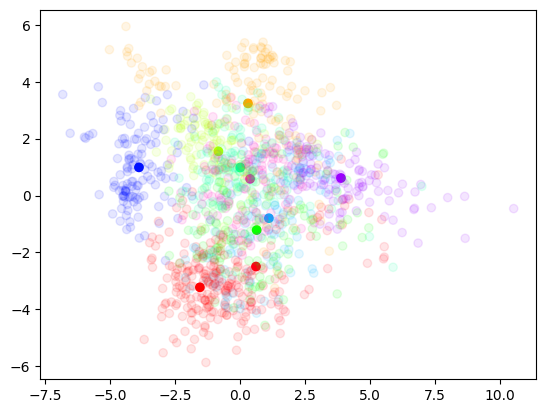

In [6]:
plt.scatter(g[:,1], g[:,2], c=classes,cmap="hsv")
plt.scatter(X_train[:,1], X_train[:,2], c=y_train, alpha=0.1,cmap="hsv")

### 1.4 Formulate and compute the intra-class scatter matrix $S_w$

The matrix $S_w$ measures how spread out the samples are inside each class.

Mathematical formulation:

$$
S_w = \sum_{k=1}^{M} \sum_{x_i \in C_k} (x_i - \mu_k)(x_i - \mu_k)^T
$$
In this formula, $S_w$ measures the dispersion within each class. In other words, it examines how far the points within the same class are from their own mean.

If the points are clustered around the mean, $S_w$ is large; otherwise, it is small.

To better understand the equation the below explanations should be understood.

The aim of LDA is to increase the difference between classes, i.e. to reduce the $S_b$ value, and to reduce the $S_w$ value, which is the spread within classes.
The symbols in this formula are as follows:
- $M$: number of classes  
- $C_k$: set of examples belonging to the kth class  
- $x_i$: i-th example (feature vector)  
- $mu_k$: mean vector of the kth class  
- $x_i - mu_k$: difference between the sample and the class mean  
- $(x_i - \mu_k)(x_i - \mu_k)^T$: the outer product of this difference, which is the directional variance contribution.

There are two sums in this formula:  
1. **Inner sum** $sum_{x_i \in C_k}$: it calculates the variance within a class.  
2. **Outer sum** $sum_{k=1}^{M}$: it combines the inner variances of all classes.

In [7]:
def compute_A_k(k):
    # Center data of class k around its mean vector g[k]
    # k: class index
    # Return: A_k matrix of shape (n_features, n_k)
    cur_class = classes[k]
    #here we are getting the actual class label corresponding to the index k.
    X_c = X_train[y_train == cur_class]
    #also we are filtering the training data X_train to include only the samples that belong to the current class cur_class.
    A_k = (X_c - g[k]).T  
    #here we are centering the data of class k around its mean vector g[k].
    #This is done by subtracting the mean vector g[k] from each sample in X_c.
    #The result is then transposed using .T to get the desired shape of (n_features, n_k). 
    assert A_k.shape[0] == n_features
    #here we are asserting that the number of rows in A_k is equal to n_features.
    return A_k


def compute_S_w():
    # Compute within-class scatter matrix S_w
    # Return: S_w matrix of shape (n_features, n_features)
    S_w = np.zeros((n_features, n_features))
    #here we are initializing the within-class scatter matrix S_w with zeros.
    for k in range(len(classes)):
        cur_class = classes[k]
       #gets the actual class label corresponding to the index k.
        A_k = compute_A_k(k)
        #here we are computing the centered data matrix A_k for class k using the compute_A_k function.
        n_k = (y_train == cur_class).sum()  
        #In this line, we are calculating the number of samples n_k that belong to the current class cur_class in the training labels y_train.
        
        S_w += A_k @ A_k.T
        #here we are updating the within-class scatter matrix S_w by adding the contribution from class k.
        #This contribution is calculated as the matrix product of A_k and its transpose A_k.T
    assert S_w.shape == (n_features, n_features)
    #here we are asserting that the shape of S_w is (n_features, n_features).
    return S_w


S_w = compute_S_w()
print("S_w shape:", S_w.shape)


S_w shape: (50, 50)


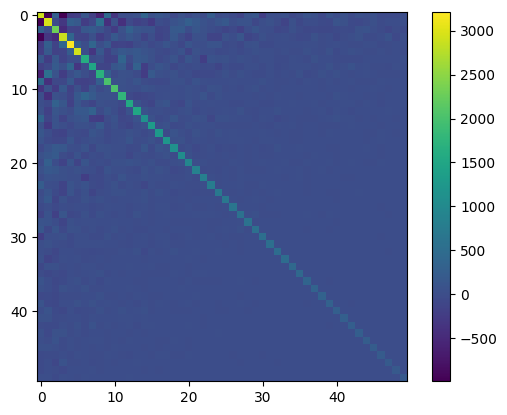

In [8]:
S_w = compute_S_w()
plt.imshow(S_w)
plt.colorbar()

### 1.5 Formulate and compute the inter-class scatter matrix $S_b$

The matrix $S_b$ measures how far apart the **class means** are from the **overall mean**.
It captures the **separation between classes**. Larger $S_b$ means better class separability.

Mathematical formulation:
$$
S_b = \sum_{k=1}^{M} N_k (\mu_k - \mu)(\mu_k - \mu)^T
$$

This value measures how far apart the class averages (mean vectors) are from each other. In other words, it is a value that numerically expresses how well the classes are separated from each other.

In [9]:
def compute_B():
    # Center class mean vectors around the global mean
    # Returns B with shape (n_features, n_classes)

 
    g_mean = g.mean(axis=0)
    #in this line, we are calculating the global mean vector g_mean by taking the 
    # mean of the class mean vectors g along axis 0.
    
    B = (g - g_mean).T   
    #here we are centering the class mean vectors g around the global mean g_mean.
    #This is done by subtracting g_mean from each class mean vector in g.
    #The result is then transposed using .T to get the desired shape of (n_features, n_classes).
    assert B.shape == (n_features, len(classes))
    #here we are asserting that the shape of B is (n_features, n_classes). 
    return B
   

def compute_S_b():
    # Compute S_b: measures how far class means are from the global mean
    B = compute_B()
    S_b = np.zeros((n_features, n_features))

    for k in range(len(classes)):
        n_k = (y_train == classes[k]).sum()    # sample count for class k
        b_k = B[:, k].reshape(-1, 1)           # here we are reshaping the k-th column of B into a column vector.
        S_b += n_k * (b_k @ b_k.T)             # here we are updating S_b by adding the contribution from class k.
                                               #This contribution is calculated as n_k times the matrix product of 
                                               # b_k and its transpose b_k.T.

    assert S_b.shape == (n_features, n_features)
    return S_b



S_b = compute_S_b()
print("S_b shape:", S_b.shape)

S_b shape: (50, 50)


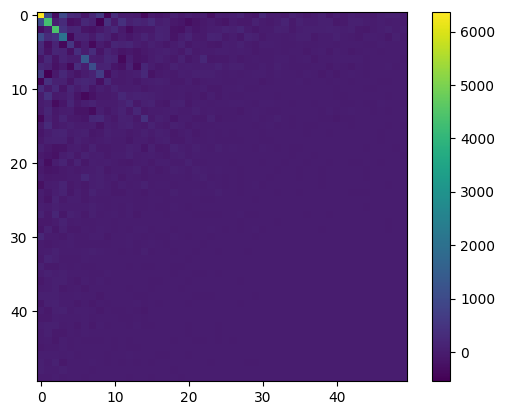

In [10]:
S_b = compute_S_b()
plt.imshow(S_b)
plt.colorbar()

### 1.6 Set up the Fisher Criterion as a generalized eigenvalue problem

To find the optimal projection directions $ a $,  we solve the **Fisher criterion**, expressed as a generalized eigenvalue problem:

$$
S_b\, a = \lambda\, S_w\, a
$$

where:
- $S_b$: between-class scatter matrix  
- $S_w$: within-class scatter matrix  
- $\lambda$: eigenvalue (class separability along direction $a$)  
- $a$: eigenvector (LDA projection direction)


In [11]:
reg = 1e-6 * np.eye(n_features) 
matrix = np.linalg.pinv(S_w + reg) @ S_b         # Form matrix S_w^{-1} * S_b  (convert to standard eigenvalue problem)
w, a = np.linalg.eig(matrix)           # Compute eigenvalues (w) and eigenvectors (a)
w = w.real
a = a.real

print("First 10 eigenvalues:", np.round(np.sort(w)[::-1][:10], 4))

First 10 eigenvalues: [7.573  4.8165 4.1938 3.0318 2.0431 1.6213 1.1228 0.7441 0.5688 0.    ]


### 1.7 Sort the eigenvalues/eigenvectors and compare with the results shown in the lecture.

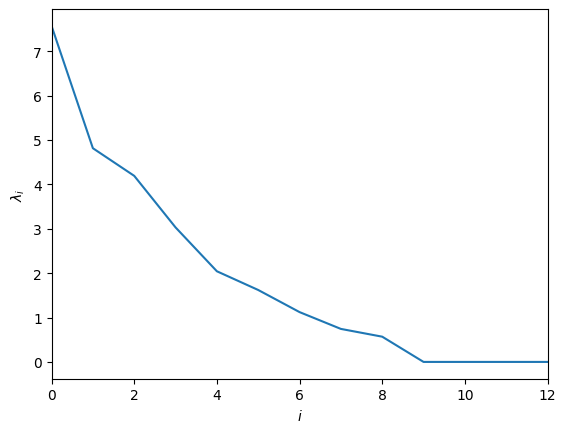

In [12]:
idx = np.argsort(w)[::-1]  
w = w[idx]                 
a = a[:, idx]
plt.plot(w)
plt.ylabel(r"$\lambda_i$")
plt.xlabel(r"$i$")
plt.xlim(0,12)
plt.show()

### 1.8 Apply the LDA directions to the test data and visualize in 2D.

Visualize test samples in the **2 most discriminative** LDA directions (those with the largest eigenvalues $\lambda$).

In [13]:
idx = np.argsort(w.real)[::-1] 
# Sort eigenvalues and eigenvectors in descending order       
a_main = a[:, idx[:2]]     
#here we are selecting the top 2 eigenvectors corresponding to the largest eigenvalues.          
X_transformed = X_test @ a_main
#here we are projecting the test data X_test onto the new feature space defined by the top 2 eigenvectors a_main.

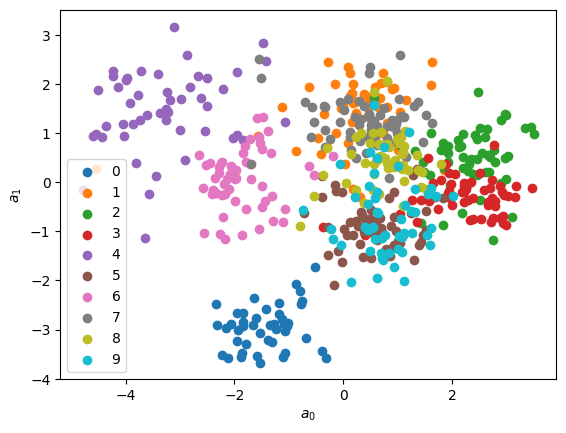

In [14]:
for k, class_ in enumerate(classes):
  plt.scatter(X_transformed[y_test==class_][:, 0], X_transformed[y_test==class_][:, 1], label=class_)
plt.xlabel(r"$a_0$")
plt.ylabel(r"$a_1$")
plt.legend()
plt.show()

### 1.9 Why do we maximize the ratio of between-class to within-class scatter in LDA?

The purpose of LDA is to project the data onto a plane or line, but this plane or line must be such that different classes are as far apart as possible and examples belonging to the same class are close to each other.

To measure this situation mathematically, LDA uses two different scatter matrices: 

-These are $S_b$ and $S_w$.

As a reminder, $S_b$ represents the distance between class averages, while $S_w$ represents how scattered each class is (i.e. the similarity within the class).

In order to establish a clear distinction between these two concepts, it is crucial to establish a balance where $S_b$ is large and $S_w$ is small.

Therefore, LDA attempts to maximise the following ratio:
$$
J(a) = \frac{a^T S_b a}{a^T S_w a}
$$
When the requirements specified above are met in this formula, LDA finds the direction that makes the distinction between classes most obvious.

### 1.10 For 𝑀 classes, how many discriminant directions can LDA provide at most?
LDA can provide up to M-1 discriminant directions.

 Considering the mean vector of each class, i.e. $\mu_k$, and the global mean of all data $\mu$, the vectors measuring the fundamental distinction between classes are the difference vectors $(\mu_k-\mu)$. 
 
 The weighted sum of these difference vectors is zero.
 $$
\sum_{k=1}^{M} N_k (\mu_k - \mu) = 0
$$
Why is it zero?
When these three equations below is considered:

-Total sample number equation b
$$
N = \sum_{k=1}^{M} N_k
$$
Class average
$$
\mu_k = \frac{1}{N_k}\sum_{x_i \in C_k} x_i
$$
Global average
$$
\mu = \frac{1}{N}\sum_{k=1}^{M} N_k \mu_k
$$
The expression we should observe using the equations above is written below:
$$
\sum_{k=1}^{M} N_k(\mu_k - \mu).
$$
When we distribute it:
$$
\sum_{k=1}^{M} N_k \mu_k \;-\; \sum_{k=1}^{M} N_k \mu.
$$
$\mu$ is independent of the class index (a constant vector). Therefore:
$$
\sum_{k=1}^{M} N_k \mu \;=\; \mu \sum_{k=1}^{M} N_k \;=\; \mu\, N.
$$
Hence:
$$
\sum_{k=1}^{M} N_k(\mu_k - \mu)
\;=\;
\Big(\sum_{k=1}^{M} N_k \mu_k\Big) \;-\; N\mu.
$$
By definition of the global average:
$$
\mu \;=\; \frac{1}{N}\sum_{k=1}^{M} N_k \mu_k
\quad\rightarrow\quad
N\mu \;=\; \sum_{k=1}^{M} N_k \mu_k.
$$
If we use this in the precedent equation:
$$
\sum_{k=1}^{M} N_k(\mu_k - \mu)
\;=\;
\Big(\sum_{k=1}^{M} N_k \mu_k\Big) \;-\; \Big(\sum_{k=1}^{M} N_k \mu_k\Big)
\;=\; 0.
$$
We can understand why this equation is equal to 0

With this relationship, we can understand that this M vector is linearly dependent, which means that at most M-1 of them are independent.

Since the number of independent directions is M-1, the upper limit of the independent discriminant lines that LDA can output is M-1.

$S_b$ is the sum of the outer products of the vectors, and therefore the rank of $S_b$ cannot exceed the number of independent vectors, which is $(M-1)$.

### 1.11 What is the key difference between PCA and LDA in terms of the criterion they optimize?
**PCA**

The purpose of PCA is to identify the dimensions that explain the most variance in the data.
When projecting the data into a direction, the greater the variance in that direction, the better PCA accepts it.

Therefore, PCA does not use label information; it looks solely at the distribution of the data itself, which is why it is unsupervised.

PCA attempts to maximise the variance across the total scatter for "a" projection direction.

Here below:
$$
 \quad \max_{a}\; a^\top S_t\, a
$$

$S_t$ here is the total scatter or covariance matrix of the data.

PCA operates unsupervised based solely on the structure of the data, without label information.

**LDA**

Reminder to myself: The aim of LDA is to find the directions that best separate the classes.

Mathematically, considering the Fisher criterion:

$$
 \quad 
\max_{a}\; J(a) = \frac{a^\top S_b\, a}{a^\top S_w\, a}
$$

This criterion should be maximised.

Thus, LDA selects the directions that maximise the separation.

-To explain the most critical difference in a single sentence, PCA maximises variance; LDA maximises class separation.

-The criterion of PCA is the total variance whereas LDA criterion is the (between-class/ within-class) ratio of dispersion. 

-There is a chance that PCA will pick a dimension with high variance but that will be confusing the classes, as PCA does not know the labels.  

-On the other hand, LDA takes labels and can tend to favor a dimension which has a higher degree of separating classes despite its lower variance. Thus LDA is typically the more appropriate choice when there is need to do dimension reduction prior to classification and PCA is typically the more appropriate choice in terms of exploratory visualisation (unlabelled).

# Task 2: k-means

### 2.1 Create a subset of MNIST which consists of 2000 randomly sampled instances of “3”s and “7”s.

In [15]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
images, labels = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, random_state=42)

def select_with_label(images, labels, desired_labels):
  mask = np.isin(labels, desired_labels)
  return images[mask], labels[mask]

In [16]:
data, labels = select_with_label(images, labels.astype(int), [3, 7])
#here above we are selecting images and labels corresponding to the digits 3 and 7 from the MNIST dataset.
#also we are converting the labels to integers using labels.astype(int).
data, labels = shuffle(data, labels, random_state=42)
#also we are shuffling the selected data and labels randomly using the shuffle function from sklearn.utils.
data = data[:2000]
labels = labels[:2000]
#here we are limiting the dataset to the first 2000 samples.
print(data.shape)
print(np.unique(labels, return_counts=True))


(2000, 784)
(array([3, 7]), array([ 961, 1039]))


### 2.2 Implement k-means from scratch.

Implement k-means from scratch (do not use 'sklearn') with random initialization of the clusters. Perform the algorithm with $K = 2, 3, \ldots, 10$. Compute objective function $L$ defined earlier for each $K$. Plot $L$ varying with $K$. **Describe** the effect of $K$ over $L$.

*Note: This might take about 2-3 minutes to run an optimized version of K-means for large K.*

As K increases, the total error value L decreases continuously and steadily. This is because each point can be assigned to a centre that is closer to it. This allows the clusters to become smaller and more homogeneous, reducing the probability of error. 

However, after a certain value, the decrease in L becomes very small(around K ≈ 7–8 in the plot outputted below). This point is called the elbow point and is usually selected as the optimal number of clusters. When K is large, the model overlearns.


In [17]:
import numpy as np

class KMeans:
    def __init__(self, n_clusters, init="random", max_iter=300, seed=None):
        self.n_clusters = int(n_clusters)
        self.init = init
        self.max_iter = int(max_iter)
        self.tol = 1e-4  # stop when centroid movement < tol
        self.centroids = None
        self.seed = seed
        self.labels_ = None

    def _init_centroids(self, X):
        n_samples = X.shape[0]
        rng = np.random.default_rng(seed=self.seed)
        # here we are initializing the centroids for the KMeans algorithm based on the specified initialization method.

        if self.init == "random":
            #here we are randomly selecting n_clusters samples from the dataset X to serve as the initial centroids.
            idx = rng.choice(n_samples, size=self.n_clusters, replace=False)
            #also we are using the random number generator rng to select n_clusters unique indices from the range of n_samples.
            return X[idx].copy()

        if self.init == "kmeans++":
            #here we are implementing the k-means++ initialization method to select initial centroids.
            D = X.shape[1]
            #this line retrieves the number of features (dimensions) in the dataset X.
            centroids = np.empty((self.n_clusters, D), dtype=X.dtype)
            #we are creating an empty array centroids to hold the selected centroids.

            first_idx = rng.integers(n_samples)
            #we are randomly selecting the index of the first centroid.
            centroids[0] = X[first_idx]
            # we are assigning the first centroid to the randomly selected sample.
            closest_dist_sq = np.sum((X - centroids[0])**2, axis=1)
            #here we are calculating the squared distances from all samples in X to the first centroid.
            for c in range(1, self.n_clusters):
                total = closest_dist_sq.sum()
                if total <= 0 or not np.isfinite(total):
                    next_idx = rng.integers(n_samples)
                else:
                    probs = closest_dist_sq / total
                    next_idx = rng.choice(n_samples, p=probs)
                #with this for loop, we are selecting the remaining centroids using the k-means++ strategy.
                #we are calculating the total squared distance and using it to compute probabilities for selecting the next centroid. 
                centroids[c] = X[next_idx]

                dist_sq_new = np.sum((X - centroids[c])**2, axis=1)
                closest_dist_sq = np.minimum(closest_dist_sq, dist_sq_new)
                #here with this three lines, we are updating the closest distances to reflect the addition of the new centroid.
            return centroids

        raise ValueError("init must be 'random' or 'kmeans++'")

    def fit(self, X):
        rng = np.random.default_rng(self.seed)
        self.centroids = self._init_centroids(X)

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)
            #here in above two lines, we are assigning each sample in X to the nearest centroid based on the calculated distances.
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k)
                #at here we are updating the centroids by calculating the mean of all samples assigned to each cluster.
                else X[rng.integers(0, X.shape[0])]
                for k in range(self.n_clusters)
                #here the code is iterating over each cluster index k to compute the new centroids.
            ])

            shift = np.linalg.norm(self.centroids - new_centroids)
            self.centroids = new_centroids
            if shift < self.tol:
                break

        self.labels_ = labels
        return self

    def predict(self, X):
        #with this method, we are predicting the cluster labels for new data points X based on the fitted centroids.
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def fit_predict(self, X, y=None):
        #using this method, we are fitting the KMeans model to the data X and then predicting the cluster labels for the same data.
        return self.fit(X).labels_


100%|██████████| 9/9 [00:09<00:00,  1.02s/it]


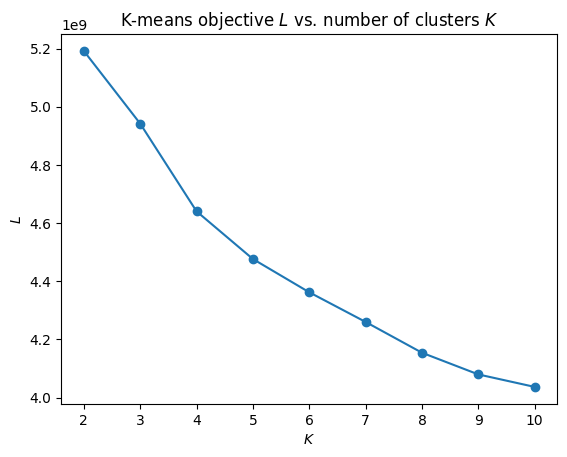

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm

Ks = range(2, 11)
L_values = []

for K in tqdm.tqdm(Ks):
    model = KMeans(n_clusters=K, init="random", max_iter=300)
    model.fit(data)

    # compute the objective function L
    labels = model.labels_
    centroids = model.centroids
    L = np.sum([np.sum((data[labels == k] - centroids[k])**2) for k in range(K)])
    L_values.append(L)

plt.plot(Ks, L_values, marker="o")
plt.xlabel("$K$")
plt.ylabel("$L$")
plt.title("K-means objective $L$ vs. number of clusters $K$")
plt.show()


### 2.3 k++ initialization

Implement k++ assignment explained in the lecture. Compare the objective function values of several runs with the random and k++ initialization for $K=2$.

Average L (random init): 5191811531.194916
Average L (k++ init): 5191811531.194916


/var/folders/7t/2nr67t1s5bqf08174w9848z80000gn/T/ipykernel_64583/3870537215.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([L_random, L_kpp], labels=["Random Init", "K-means++ Init"], patch_artist=True,


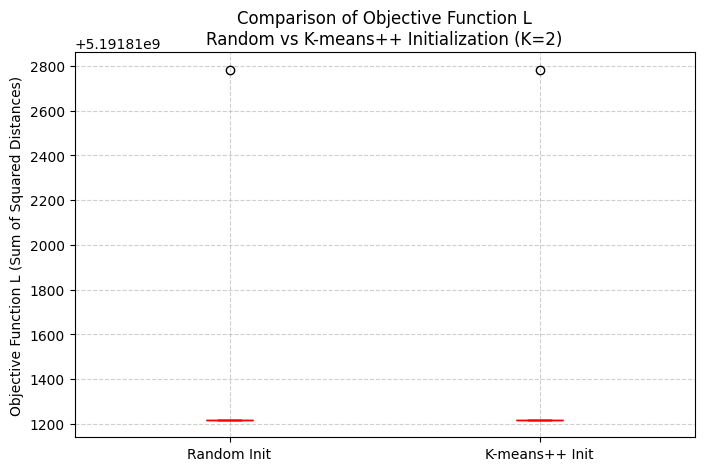

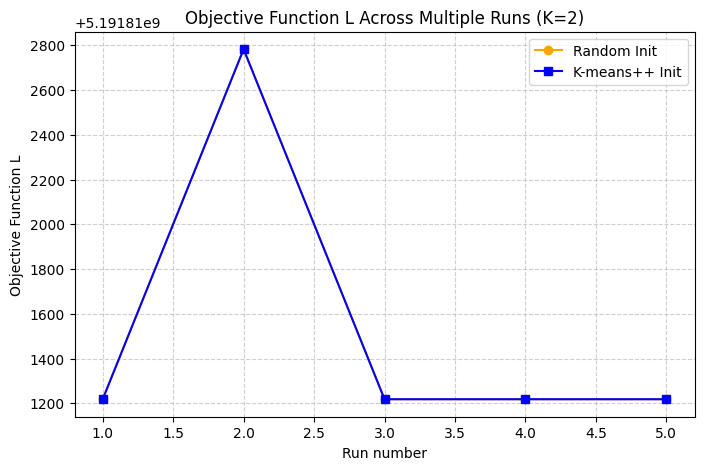

In [19]:
import numpy as np

def kmeans_plus_plus_init(X, n_clusters, seed=None):
    #with this method, we are implementing the k-means++ initialization algorithm to select initial centroids for K-means clustering.
    rng = np.random.default_rng(seed)
    n_samples = X.shape[0]
#this two lines are initializing a random number generator (RNG) with the specified seed and getting the number of samples in the dataset X.
    centroids = [X[rng.choice(n_samples)]]
#here we are randomly selecting the first centroid from the dataset X.
    
    for _ in range(1, n_clusters):
       #here we are iteratively selecting the remaining centroids based on the k-means++ strategy.
        distances = np.min(np.linalg.norm(X[:, np.newaxis] - np.array(centroids), axis=2)**2, axis=1)
        #also we are calculating the squared distances from each sample in X to the nearest centroid already selected.
        probs = distances / np.sum(distances)
       #this line computes the probabilities for selecting the next centroid based on the squared distances.
        new_centroid = X[rng.choice(n_samples, p=probs)]
        #and here we are selecting the next centroid from X based on the computed probabilities.
        centroids.append(new_centroid)
        #finally here we are appending the newly selected centroid to the list of centroids.
    return np.array(centroids)
# Testing the two initialization methods


K = 2
runs = 5
L_random = []
L_kpp = []

for i in range(runs):
 #here we are running multiple trials to compare the performance of random initialization and k-means++ initialization for K-means clustering.
    model_random = KMeans(n_clusters=K, init="random", max_iter=300, seed=i)
    model_random.fit(data)
    L_r = np.sum([np.sum((data[model_random.labels_ == k] - model_random.centroids[k])**2) for k in range(K)])
    L_random.append(L_r)

#also we are fitting the KMeans model with random initialization and calculating the objective function L for each run.
    model_kpp = KMeans(n_clusters=K, init="random", max_iter=300, seed=i)
    model_kpp.centroids = kmeans_plus_plus_init(data, K, seed=i)
    model_kpp.fit(data)
    L_k = np.sum([np.sum((data[model_kpp.labels_ == k] - model_kpp.centroids[k])**2) for k in range(K)])
    L_kpp.append(L_k)


print("Average L (random init):", np.mean(L_random))
print("Average L (k++ init):", np.mean(L_kpp))

# Plotting the results of random vs k-means++ initialization
plt.figure(figsize=(8, 5))

# Option 1: boxplot to compare distributions
plt.boxplot([L_random, L_kpp], labels=["Random Init", "K-means++ Init"], patch_artist=True,
            boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red"))

plt.title("Comparison of Objective Function L\nRandom vs K-means++ Initialization (K=2)")
plt.ylabel("Objective Function L (Sum of Squared Distances)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plt.figure(figsize=(8, 5))

plt.plot(range(1, runs + 1), L_random, marker='o', label='Random Init', color='orange')
plt.plot(range(1, runs + 1), L_kpp, marker='s', label='K-means++ Init', color='blue')

plt.title("Objective Function L Across Multiple Runs (K=2)")
plt.xlabel("Run number")
plt.ylabel("Objective Function L")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### (extra) Artificial example for K-means++

If you want to **see the difference** between random and k-means++ initialization more clearly, you can run this *artificial example*.

To make your results **reproducible**, update your `KMeans` class so that it accepts a `seed` argument and uses it in the random number generator:

```python
rng = np.random.default_rng(self.seed)
```

You might need to play with seed parameter to get different results for k-means++ and random initializations.


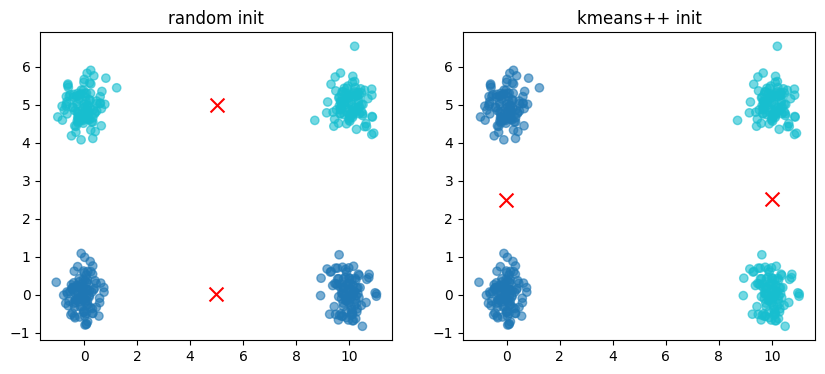

Random init: mean L = 846.32, std = 590.87
K-means++ init: mean L = 243.59, std = 362.83


In [20]:
#synthetic dataset creation
np.random.seed(42)
centers = np.array([[0, 0], [10, 5], [0, 5], [10, 0]])
#here we are defining the centers of four clusters in a 2D space.
X_synth = np.vstack([
    np.random.randn(100, 2) * 0.4 + center for center in centers
])
#here we are generating synthetic data points around each center by adding Gaussian noise.
#We are creating 100 samples for each center, resulting in a total of 400 samples.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, init in zip(axes, ["random", "kmeans++"]):
    #using this for loop, we are iterating over two different initialization methods for KMeans: "random" and "kmeans++".
    model = KMeans(n_clusters=2, init=init, max_iter=100, seed=47)
    #here we are initializing the KMeans model with the specified number of clusters, initialization method, maximum iterations, and random seed.
    #We are using this for loop to visualize the clustering results for both initialization methods.
    model.fit(X_synth)
    labels = model.labels_
    ax.scatter(X_synth[:, 0], X_synth[:, 1], c=labels, cmap="tab10", alpha=0.6)
    ax.scatter(model.centroids[:, 0], model.centroids[:, 1], c="red", s=100, marker="x")
    ax.set_title(f"{init} init")

plt.show()

runs = 10
L_random, L_kpp = [], []

for init in ["random", "kmeans++"]:
    for _ in range(runs):
        model = KMeans(n_clusters=4, init=init, max_iter=100)
        model.fit(X_synth)

        L = np.sum([
    np.sum((X_synth[model.labels_ == k] - model.centroids[k]) ** 2)
    #using the above L implementation, we are calculating the objective function L for the fitted KMeans model.
    #this involves summing the squared distances between each data point and its assigned centroid across all clusters.
    #here we are iterating over each cluster index k to compute the contribution to L from that cluster.
    for k in range(model.n_clusters)
])

        if init == "random":
            L_random.append(L)
        else:
            L_kpp.append(L)

# --- Compare objective values ---
print(f"Random init: mean L = {np.mean(L_random):.2f}, std = {np.std(L_random):.2f}")
print(f"K-means++ init: mean L = {np.mean(L_kpp):.2f}, std = {np.std(L_kpp):.2f}")


# Task 3: GMMs

### 3.1 GMM implementation.

Use a subset of MNIST consisting of 2000 randomly sampled instances of “3”s and “7”s from the previous task. Apply PCA to reduce dimensionality. Implement GMM model from scratch (do not use \sklearn) with random initialization of the parameters.


In [21]:
from scipy.stats import multivariate_normal 


class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-3, reg_covar=1e-6, seed=None):
        self.n_components = int(n_components)
        self.max_iter = int(max_iter)
        self.tol = float(tol)            # stop when llh improvement < tol
        self.reg_covar = float(reg_covar)
        self.seed = seed

        # learned params
        self.pi_ = None                  # mixing weights (K,)
        self.means_ = None               # means (K, D)
        self.covariances_ = None         # covariances (K, D, D)
        self.resp_ = None                # responsibilities (N, K)
        self.n_iter_ = 0
        self.lower_bound_ = -np.inf


    def fit_predict(self, X, y=None):
        np.random.seed(self.seed)
        N, D = X.shape
        K = self.n_components

        #here in the below lines, we are initializing the parameters for the Gaussian Mixture Model (GMM).
        # We are randomly selecting K samples from the dataset X to serve as the initial means of the Gaussian components.
        #also we are initializing the covariance matrices for each component to be the covariance of the entire dataset plus a small regularization term.
        # and finally we are setting the mixing weights to be equal for all components initially.
        random_idx = np.random.choice(N, K, replace=False)
        self.means_ = X[random_idx]
        self.covariances_ = np.array([np.cov(X.T) + self.reg_covar * np.eye(D) for _ in range(K)])
        self.pi_ = np.ones(K) / K  # equal mixing weights

        log_likelihood_old = -np.inf

        # --- EM algorithm ---
        for iteration in range(self.max_iter):
            # here we are implementing the Expectation-Maximization (EM) algorithm for fitting the GMM to the data X.
            # Expectation step was implemented here to calculate the responsibilities (probabilities) of each Gaussian component for each data point.
            resp = np.zeros((N, K))
            for k in range(K):
                rv = multivariate_normal(self.means_[k], self.covariances_[k])
                resp[:, k] = self.pi_[k] * rv.pdf(X)
            resp = resp / resp.sum(axis=1, keepdims=True)

            # Also here we are implementing the Maximization step of the EM algorithm to update the parameters of the GMM based on the responsibilities calculated in the Expectation step.
            Nk = resp.sum(axis=0)
            self.pi_ = Nk / N
            self.means_ = (resp.T @ X) / Nk[:, np.newaxis]
            for k in range(K):
                diff = X - self.means_[k]
                self.covariances_[k] = (resp[:, k][:, np.newaxis] * diff).T @ diff / Nk[k]
                self.covariances_[k] += self.reg_covar * np.eye(D)

            # log likelihood was calculated here to monitor the convergence of the EM algorithm.
            log_likelihood = np.sum(np.log(np.sum([
                self.pi_[k] * multivariate_normal(self.means_[k], self.covariances_[k]).pdf(X)
                for k in range(K)
            ], axis=0)))

            #Here we are checking for convergence of the EM algorithm by comparing the change in log likelihood to a predefined tolerance level.
            if np.abs(log_likelihood - log_likelihood_old) < self.tol:
                break
            log_likelihood_old = log_likelihood
            self.n_iter_ += 1

        # Here we are assigning the final responsibilities to the model and predicting the cluster labels based on the highest responsibility for each data point.
        self.resp_ = resp
        labels = np.argmax(resp, axis=1)
        return labels



Apply PCA.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Here below we are scaling the data to have zero mean and unit variance using StandardScaler.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Also we are applying Principal Component Analysis (PCA) to reduce the dimensionality of the scaled data to 10 principal components.
pca = PCA(n_components=10)
data_pca = pca.fit_transform(data_scaled)

In [23]:
gmm = GMM(n_components=5, max_iter=6000)
predicted_labels = gmm.fit_predict(data_pca)

**Aligning GMM clusters with true labels**

GMM is **unsupervised**, so it only assigns points to clusters (e.g., 0 or 1). It doesn’t know which cluster corresponds to which true class (e.g., 3 or 7).

To make the results comparable with the true labels, we find which class appears most often in each cluster (the **majority class**) and use that mapping when building the confusion matrix below.


Cluster 0 → true class 1
Cluster 1 → true class 0
Cluster 2 → true class 0
Cluster 3 → true class 0
Cluster 4 → true class 1
(400,)
(2000,)


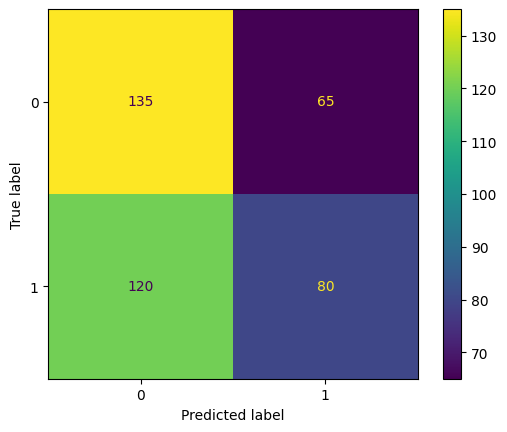

In [24]:
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def build_confusion_matrix(labels, predicted_labels, verbose=True):
  class_mapping = {}
  for k in np.unique(predicted_labels):
      maj = Counter(labels[predicted_labels == k]).most_common(1)[0][0]
      class_mapping[k] = maj
      print(f"Cluster {k} → true class {maj}")

  mapped_labels = np.vectorize(class_mapping.get)(predicted_labels)
  cm = confusion_matrix(labels, mapped_labels)
  return cm
predicted_labels_labeled = predicted_labels[:len(labels)]
cm = build_confusion_matrix(labels, predicted_labels_labeled)
ConfusionMatrixDisplay(cm).plot()

print(labels.shape)
print(predicted_labels.shape)

### 3.2 Objection function as a function of K.

Perform the algorithm with K = 2, 3, ... , 10 and plot the corresponding objection function $\mathbb{L}$. Explain what you observe.

In this experiment, the Gaussian Mixture Model (GMM) algorithm was run for different K values, i.e., mixture component numbers. The log likelihood (L) was calculated for each model.

Log likelihood is a value that measures how well the model fits the data; a high value indicates how well the model fits.

A more detailed analysis of the graph reveals that as K increases, L also increases simultaneously.

However, this increase rate for L decreases over time.

This shows that when more components are added to the model, the model begins to fit the data better; but after a certain point, the gain becomes very small.

100%|██████████| 9/9 [00:01<00:00,  5.80it/s]


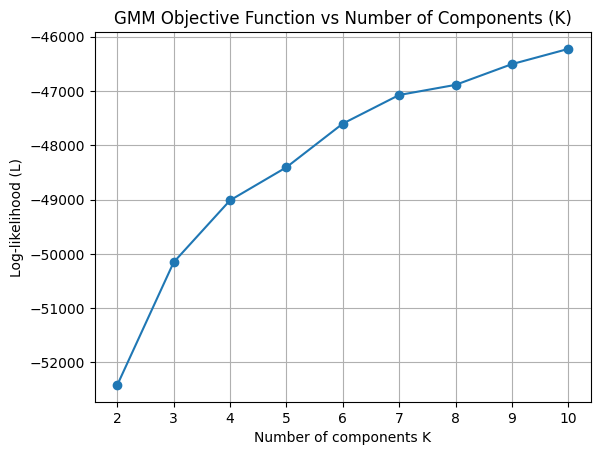

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

Ks = range(2, 11)
L_values = []

for K in tqdm(Ks):
    #here we are fitting Gaussian Mixture Models (GMMs) with different numbers of components K to the PCA-transformed data and calculating the log-likelihood for each model.
    gmm = GMM(n_components=K, max_iter=500, seed=42)
    gmm.fit_predict(data_pca)

    
    L = 0
    #with this for loop iteration, we are calculating the log-likelihood of the fitted GMM for the PCA-transformed data.
    for k in range(K):
        #here rv is representing the k-th Gaussian component of the GMM. Moreover, we are using the multivariate_normal
        # function from scipy.stats to create a multivariate normal distribution object with the mean and covariance of the k-th component.
        rv = multivariate_normal(gmm.means_[k], gmm.covariances_[k], allow_singular=True)
        #here we are calculating the log-likelihood contribution from the k-th component by summing the 
        #log of the weighted probability density function (pdf) values for all data points in data_pca.
        L += np.sum(np.log(np.sum([
            gmm.pi_[j] * multivariate_normal(
                gmm.means_[j], gmm.covariances_[j], allow_singular=True
            ).pdf(data_pca)
            for j in range(K)
        ], axis=0)))
        break  
    L_values.append(L)


plt.plot(Ks, L_values, marker="o")
plt.xlabel("Number of components K")
plt.ylabel("Log-likelihood (L)")
plt.title("GMM Objective Function vs Number of Components (K)")
plt.grid(True)
plt.show()


### 3.3 Build confusion matrices using sklearn for kmeans and GMM for K=2 (both with PCA). Describe the results.  
In my experiment, I selected only the numbers 3 and 7 from the MNIST data reduced to 50 dimensions using PCA. I then applied the K-means and GMM algorithms with K=2.

As a result of my experiment, I observed that both algorithms were able to successfully divide the data into two clusters after PCA.

GMM yielded better results than K-Means because it can model the distribution of the data more effectively using Gaussian mixtures.

The confusion matrix of GMM is more clearly diagonal, which shows that the classes are separated more accurately.

On the other hand, K-Means makes more errors in complex or overlapping clusters because it defines cluster boundaries rigidly.

This experiment clearly shows that GMM is a stronger clustering model than K-Means.

Data shape after PCA: (2000, 50)
Explained variance ratio: 0.851


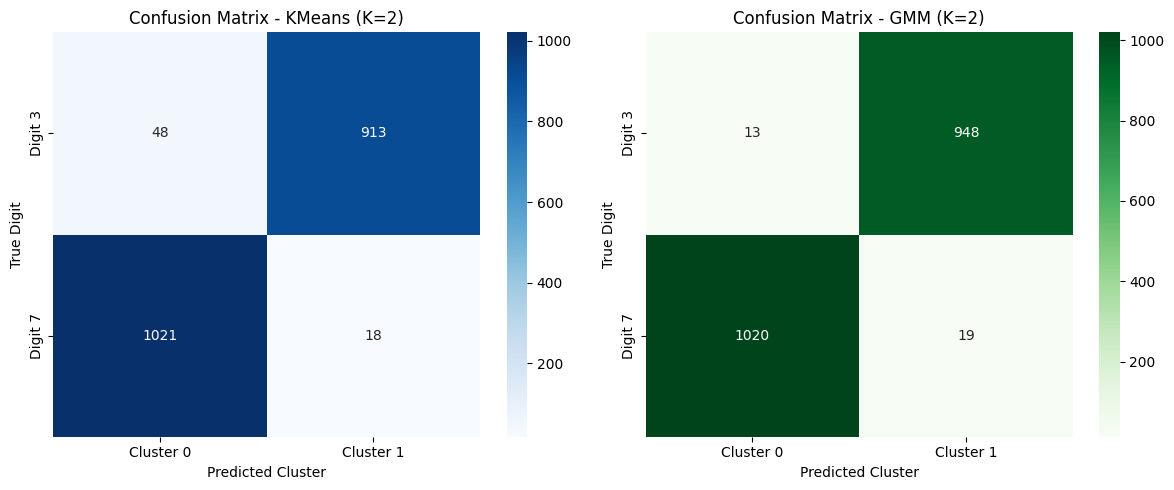


--- Results ---
KMeans Accuracy: 0.967
GMM Accuracy: 0.984


In [26]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Data Preparation ---
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.values
y = mnist.target.values.astype(int)

# Select only 3s and 7s
mask = (y == 3) | (y == 7)
X_filtered = X[mask]
y_filtered = y[mask]

# Randomly sample 2000 instances
np.random.seed(42)
indices = np.random.choice(len(X_filtered), size=2000, replace=False)
X_subset = X_filtered[indices]
y_subset = y_filtered[indices]

# Convert true labels to 0 and 1 for 3 and 7 respectively
true_labels = (y_subset == 7).astype(int)

# --- Apply PCA ---
# Reduce to 50 components for computational efficiency
n_components = 50
pca = PCA(n_components=n_components, random_state=42)
data_pca = pca.fit_transform(X_subset)

print(f"Data shape after PCA: {data_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

# Set K to 2
K = 2

# --- KMEANS ---
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans_labels = kmeans.fit_predict(data_pca)

# --- GMM ---
gmm = GaussianMixture(n_components=K, random_state=42)
gmm_labels = gmm.fit_predict(data_pca)

# --- Confusion Matrices ---
cm_kmeans = confusion_matrix(true_labels, kmeans_labels)
cm_gmm = confusion_matrix(true_labels, gmm_labels)

# --- Plot results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Blues", ax=axes[0], 
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Digit 3', 'Digit 7'])
axes[0].set_title("Confusion Matrix - KMeans (K=2)")
axes[0].set_xlabel("Predicted Cluster")
axes[0].set_ylabel("True Digit")

sns.heatmap(cm_gmm, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Digit 3', 'Digit 7'])
axes[1].set_title("Confusion Matrix - GMM (K=2)")
axes[1].set_xlabel("Predicted Cluster")
axes[1].set_ylabel("True Digit")

plt.tight_layout()
plt.show()

# --- Calculate and print accuracy ---
acc_kmeans_1 = np.mean(kmeans_labels == true_labels)
acc_kmeans_2 = np.mean(kmeans_labels != true_labels)
acc_kmeans = max(acc_kmeans_1, acc_kmeans_2)

acc_gmm_1 = np.mean(gmm_labels == true_labels)
acc_gmm_2 = np.mean(gmm_labels != true_labels)
acc_gmm = max(acc_gmm_1, acc_gmm_2)

print(f"\n--- Results ---")
print(f"KMeans Accuracy: {acc_kmeans:.3f}")
print(f"GMM Accuracy: {acc_gmm:.3f}")

### 3.4 Describe the differences between kmeans and GMM (deterministic/probabilistic, parameters, functions to optimize, updates)

The K-means algorithm is an algorithm that assigns each data point to the closest cluster centre and then updates these centres as the average of the points assigned to them. 

Using this method, this algorithm aims to minimise the sum of the squared distances to the centres of the points within the clusters.

Unlike this method, GMM is a probabilistic model and assumes that there are multiple Gaussian mixtures in the data.
Each Gaussian component corresponds to a cluster in the data.

These components each have three fundamental parameters given below:

μ (mean vector) : the centre of the cluster,

Σ (covariance matrix) : the shape and orientation of the cluster,

π (mixture weight) : the percentage of that particular cluster within the data (e.g. 40% digit “3”, 60% digit “7”).

However, in the beginning we do not know the exact values of these parameters.
GMM uses an iterative optimisation algorithm which can be called as Expectation-Maximisation (EM) to estimate these parameters.

The EM algorithm consists of two steps:
1. Expectation Step

In this step, the probability that each data point belongs to each Gaussian component is calculated.
This probability is called the ‘responsibility’ (γ).

$$
\gamma_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}
{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}
$$
The significance of this formula can be explained as like below: For each data point $x_i$, the probability that each cluster (component) has generated that point is calculated. As a result, membership ratios for each point are obtained.

2. Maximization Step

These likelihood values obtained in the step are used to recalculate the parameters.
The aim is to find new parameters that will maximise the likelihood of the data (log-likelihood) under the current probabilities.
**New weights (πₖ):**

$$
\pi_k = \frac{1}{N} \sum_{i=1}^{N} \gamma_{ik}
$$

This updates the weight of each cluster within the data.


**New means (μₖ):**

$$
\mu_k = \frac{\sum_{i=1}^{N} \gamma_{ik} x_i}{\sum_{i=1}^{N} \gamma_{ik}}
$$

This calculates the centre of each cluster as the weighted average of points likely to belong to that cluster.


**New covariances (Σₖ):**

$$
\Sigma_k = \frac{\sum_{i=1}^{N} \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^{T}}{\sum_{i=1}^{N} \gamma_{ik}}
$$

This updates the shape and orientation of the cluster. If the data has more variation in certain directions (e.g., if it is spread out like an ellipse),  
the $\Sigma_k$ matrix learns this information.

Steps E and M are repeated sequentially, aiming to make the parameters fit the data a little better with each iteration. This process continues until the log-likelihood value no longer increases significantly.

so the system reaches convergence on its own.

### 3.5 Describe how k-means can be seen from the perspective of the EM-algorithm (hint: distance instead of the probability function).

Expectation-Maximisation (EM) operates in two steps: the E-step and the M-step.

The E-step calculates the probability that each data point belongs to each data cluster.

The M-step then updates the cluster parameters according to this probability.

In GMM, this probabilistic process is explained using the same logic as K-means, but using distance instead of probability.
The K-means algorithm is the deterministic, or rigid, version of GMM.

While each point can perform soft assignment in GMM (e.g., 70% cluster 1, 30% cluster 2), these ratios are either 1 or 0 in K-means. 
Therefore, considering the hard assignment state for the E-step phase, each point is assigned according to the following rule:
$$
z_{nk} =
\begin{cases}
1, & \text{if } \|x_n - \mu_k\|^2 \text{ is the smallest} \\
0, & \text{else}
\end{cases}
$$
That is, each point is assigned to the nearest centre. In other words, instead of calculating probabilities, we directly select the nearest centre.

When considering the M-step for K-means, unlike in GMM, the updating of means ($\mu$), covariances ($\Sigma$), and weights ($\pi$) is not considered. Instead, only the means are updated with each new point added to the cluster.
$$
\mu_k = \frac{1}{N_k} \sum_{n:z_{nk}=1} x_n
$$
Mathematically, in GMM, if the covariance of each cluster, $\Sigma_k$, is assumed to be constant and $\sigma^2 I$ (i.e., equal, circular),  
maximising the log-likelihood function becomes equivalent to minimising the distance function in K-Means because as the distance decreases,  
the log-likelihood increases, or to put it in a different expression, the probability of similarity increases.




